<a href="https://colab.research.google.com/github/gwenstew/moviereccomender/blob/main/movereccomender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns
from sklearn.model_selection import train_test_split
file_path = 'drive/MyDrive/ml-latest-small/ratings.csv'
df = pd.read_csv(file_path)
print(df.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [ ]:
movies_df = pd.read_csv('drive/MyDrive/ml-latest-small/movies.csv')
print(movies_df.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [ ]:
df.drop('timestamp', axis=1, inplace=True)
print(df.head())

   userId  movieId  rating
0       1        1     4.0
1       1        3     4.0
2       1        6     4.0
3       1       47     5.0
4       1       50     5.0


In [ ]:
print(df.isnull().sum())
print(df.isnull().sum(axis=1))

userId     0
movieId    0
rating     0
dtype: int64
0         0
1         0
2         0
3         0
4         0
         ..
100831    0
100832    0
100833    0
100834    0
100835    0
Length: 100836, dtype: int64


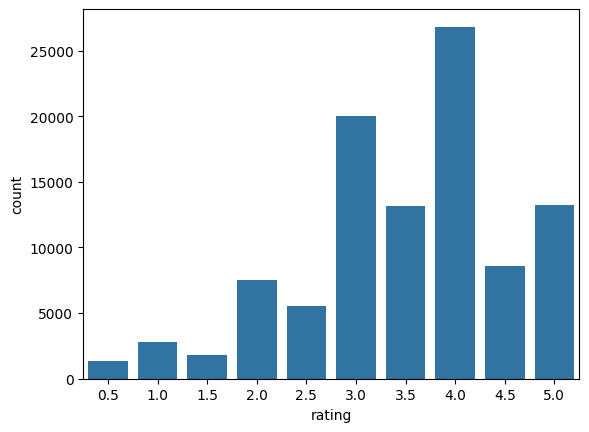

In [ ]:
# plot distribution of ratings
sns.countplot(x='rating', data=df)
plt.show()



In [ ]:
# count number of users with no ratings
no_ratings = df.groupby('userId')['movieId'].count().reset_index()
no_ratings.columns = ['userId', 'num_ratings']
no_ratings = no_ratings[no_ratings['num_ratings'] == 0]
print(no_ratings.size)

0


In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

#Building user-item matrix for training

n_users = train['userId'].nunique()
n_items = train['movieId'].nunique()

user_ids = train['userId'].unique()
item_ids = train['movieId'].unique()

user_map = {uid: i for i, uid in enumerate(user_ids)}
item_map = {iid: i for i, iid in enumerate(item_ids)}

R = np.zeros((n_users, n_items))

for row in train.itertuples():
    R[user_map[row.userId], item_map[row.movieId]] = row.rating

print(f"Number of users: {n_users:,}")
print(f"Number of movies: {n_items:,}")
print(f"Train set shape: {train.shape}")
print(f"Test set shape:  {test.shape}")
print(f"User–Item matrix shape: {R.shape}")


Number of users: 610
Number of movies: 8,983
Train set shape: (80668, 3)
Test set shape:  (20168, 3)
User–Item matrix shape: (610, 8983)


In [ ]:
# calculate sparsity of matrix
sparsity = 1 - (np.count_nonzero(R) / R.size)
print(f"Sparsity: {sparsity * 100:.2f}%")

Sparsity: 98.53%


In [ ]:
test = test[test.userId.isin(user_map.keys()) & test.movieId.isin(item_map.keys())]

# Naive Baseline Predictions (User/item)

These functions predict a rating based solely on the average of the past ratings

In [ ]:
def user_mean(user, item, R):
    # returns the mean rating for user or the global mean if the user has not yet made a rating
    user_ratings = R[user,:]
    rated = np.where(user_ratings != 0)[0]
    return np.mean(user_ratings[rated]) if len(rated) > 0 else np.mean(R[R>0])

def item_mean(user, item, R):
    # returns the mean rating for item or the global mean if the movie has not yet been rated
    movie_ratings = R[:,item]
    rated = np.where(movie_ratings != 0)[0]
    return np.mean(movie_ratings[rated]) if len(rated) > 0 else np.mean(R[R>0])


# Cosine Similarity & KNN Predictions

$$cos(Θ) = \frac{\vec{a}\cdot \vec{b}}{||\vec{a}||\cdot||\vec{b}||}$$

Cosine similarity measures the angle between two vectors, indicating their similarity with a score [1,-1]

* $cos(\theta)$ = 1 - vectors are the same

* $cos(\theta)$ = 0 - vectors are orthogonal

* $cos(\theta)$ = -1 - vectors are opposite in direction

We will use the cosine similarity in conjuction with KNN to compare user vectors and aggregate ratings from the most similar users to make a prediction.





In [ ]:
def cosine_similarity(a, b):
  # we only wish to evaluate co-rated movies
  rated = np.where(a*b != 0)[0]
  if len(rated) == 0:
    return 0
  return np.dot(a[rated], b[rated]) / (np.linalg.norm(a[rated]) * np.linalg.norm(b[rated]))

In [ ]:
def KNN(user, item, R, k=25):
    #for a user and item, find all other users that rated that item and compute similarity;
    # return the weighted sum of the ratings from the top k similar users
    similarity_scores = []
    for other_user in range(R.shape[0]):
        if other_user == user:
            continue
        if R[other_user, item] != 0:
            similarity_scores.append((cosine_similarity(R[user,:], R[other_user,:]), R[other_user, item]))

    if len(similarity_scores) == 0:
        return np.mean(R[R>0])
    similarity_scores.sort(key=lambda x: x[0], reverse=True)  #sort by sim-score
    return np.dot([x[0] for x in similarity_scores[:k]], [x[1] for x in similarity_scores[:k]]) / (sum([x[0] for x in similarity_scores[:k]]) + 1e-9)



# Matrix Factorization (SGD)

In [ ]:
# split training data again into train and valid
# create a train mf function that creates P and Q from random
# do hyper parameter tuning with train split and valid
# finally train mf on the full training data
# call rmse with the test and the train set

train_split, valid = train_test_split(train, test_size=0.1, random_state=42)

def train_mf(R, train, valid, K, steps, alpha, beta):
    n_users, n_items = R.shape
    P = np.random.normal(loc=0.0, scale = 1.0/K, size=(n_users, K))
    Q = np.random.normal(loc=0.0, scale = 1.0/K, size=(n_items, K))

    for step in range(steps):
        for row in train.itertuples():
            user, item, rating = user_map[row.userId], item_map[row.movieId], row.rating
            error = rating - np.dot(P[user,:], Q[item,:])
            P[user,:] += alpha * (error * Q[item,:] - beta * P[user,:])
            Q[item,:] += alpha * (error * P[user,:] - beta * Q[item,:])

    return  P, Q

In [ ]:
from tqdm import tqdm
from itertools import product
import warnings

warnings.filterwarnings("error", category=RuntimeWarning)

params = {
    "K": [5, 10, 20, 50],
    "alpha": [0.005, 0.01, 0.015],
    "beta": [0.05, 0.1, 0.2],
    "steps": [100]
}

best_rmse = float("inf")
best_params = None
best_model = None
results = []

#all parameter combinations
param_combos = list(product(params["K"], params["alpha"], params["beta"], params["steps"]))

# Wrap in tqdm for progress bar
for K, alpha, beta, steps in tqdm(param_combos, desc="Hyperparameter tuning", total=len(param_combos)):

    try:
        P, Q = train_mf(R, train, valid, K, steps, alpha, beta)

        # evaluate on validation set
        u_idx = valid.userId.map(user_map).to_numpy()
        i_idx = valid.movieId.map(item_map).to_numpy()
        predictions = np.sum(P[u_idx] * Q[i_idx], axis=1)
        rmse = sqrt(np.mean((predictions - valid.rating.to_numpy())**2))

        results.append((K, alpha, beta, steps, rmse))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (K, alpha, beta, steps)
            best_model = (P, Q)
    except RuntimeWarning:
        print(f"\nK={K}, alpha={alpha}, beta={beta}, steps={steps}")
        break

print(f"\n Best params: {best_params}")
print(f" Validation RMSE: {best_rmse:.4f}")

Hyperparameter tuning:  47%|████▋     | 17/36 [41:59<46:56, 148.22s/it]


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results, columns=["K", "alpha", "beta", "steps", "rmse"])


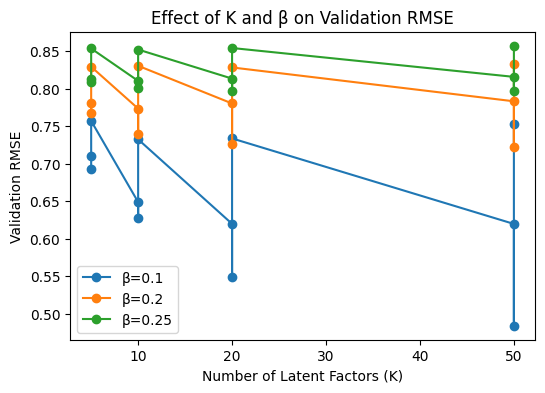

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
for beta in results_df["beta"].unique():
    subset = results_df[results_df["beta"] == beta]
    plt.plot(subset["K"], subset["rmse"], marker="o", label=f"β={beta}")
plt.xlabel("Number of Latent Factors (K)")
plt.ylabel("Validation RMSE")
plt.legend()
plt.title("Effect of K and β on Validation RMSE")
plt.show()

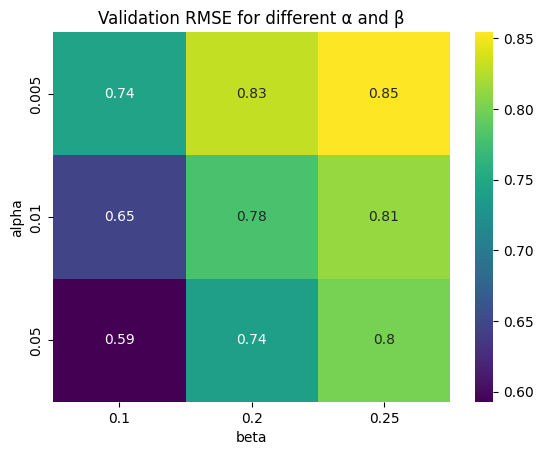

In [ ]:
import seaborn as sns

pivot = results_df.pivot_table(values="rmse", index="alpha", columns="beta")
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Validation RMSE for different α and β")
plt.show()

In [ ]:
#train full training set with best parameters
np.random.seed(42)
P, Q = train_mf(R, train, None, K=5, steps=100, alpha=0.01, beta=0.1)

In [ ]:
def predict_mf(user, item, R, P=P, Q=Q):
    return np.dot(P[user,:], Q[item,:])

In [ ]:
print(train.shape)
print(valid.shape)
print(test.shape)

(80668, 3)
(8067, 3)
(19355, 3)


# Model Evaluation RMSE

In [ ]:
from math import sqrt
def rmse(test, R, predict_fn, **args):
    errors = []
    for row in test.itertuples():
        user, item, rating = user_map[row.userId], item_map[row.movieId], row.rating
        prediction = predict_fn(user, item, R, **args)
        errors.append((prediction - rating)**2)
    return sqrt(np.mean(errors))

In [ ]:
print(rmse(test, R, user_mean))
print(rmse(test, R, item_mean))

0.9487317313519505
0.9757911622301263


In [ ]:
print(rmse(test, R, KNN))

0.9754255637322209


In [ ]:
print(rmse(test, R, predict_mf)) # K=50 steps=200 b=0.1 a=0.01 BEST RESULTS

0.886232750459787


Predicting movies that user N will like


In [ ]:
def predict_for_user(
      user_id,
      R=R,
      P=P,
      Q=Q,
      user_map=user_map,
      item_map=item_map,
      num_recommendations=10):

  if (user_id not in user_map.keys()):
    print("User not in training set")
    return

  user_idx = user_map[user_id]
  inverted_item_map = {v: k for k,v in item_map.items()}

  #score all movies for user
  scores = Q @ P[user_idx]

  #exclude movies already rated from recommendations
  rated = np.where(R[user_idx] != 0)[0]
  scores[rated] = -np.inf

  #select top n indices
  top_indices = np.argsort(scores)[::-1][:num_recommendations]

  results = pd.DataFrame(
      {
          "movieId": [inverted_item_map[i] for i in top_indices],
          "predicted_rating": scores[top_indices]
      }
  )

  #merge on movie titles
  results = results.merge(movies_df[["movieId", "title", "genres"]], on="movieId", how="left")
  results = results[["movieId", "title", "predicted_rating", "genres"]]
  return results



In [ ]:
predict_for_user(15)

,movieId,title,predicted_rating,genres
0,27611,Battlestar Galactica (2003),5.040348,Drama|Sci-Fi|War
1,141718,Deathgasm (2015),4.962109,Comedy|Horror
2,3088,Harvey (1950),4.912056,Comedy|Fantasy
3,72171,Black Dynamite (2009),4.851193,Action|Comedy
4,7841,Children of Dune (2003),4.760412,Fantasy|Sci-Fi
5,3567,Bossa Nova (2000),4.663304,Comedy|Drama|Romance
6,4789,Phantom of the Paradise (1974),4.646245,Comedy|Fantasy|Horror|Musical|Thriller
7,177593,"Three Billboards Outside Ebbing, Missouri (2017)",4.613232,Crime|Drama
8,60943,Frozen River (2008),4.583360,Drama
9,7842,Dune (2000),4.583314,Drama|Fantasy|Sci-Fi


In [ ]:
def top_rated_movies(user_id, R=R, user_map=user_map, item_map=item_map):
  if (user_id not in user_map.keys()):
    print("User not in training set")
    return
  user_ratings = df[df["userId"] == user_id][["movieId", "rating"]]

  results = (
      user_ratings
      .merge(movies_df[["movieId", "title", "genres"]], on="movieId", how="left")
      .sort_values("rating", ascending=False)
      .head(10)
      [["movieId", "title", "rating", "genres"]]
  )

  return results

In [ ]:
top_rated_movies(15)

,movieId,title,rating,genres
6,260,Star Wars: Episode IV - A New Hope (1977),5.0,Action|Adventure|Sci-Fi
22,1200,Aliens (1986),5.0,Action|Adventure|Horror|Sci-Fi
20,1196,Star Wars: Episode V - The Empire Strikes Back...,5.0,Action|Adventure|Sci-Fi
15,589,Terminator 2: Judgment Day (1991),5.0,Action|Sci-Fi
13,527,Schindler's List (1993),5.0,Drama|War
11,356,Forrest Gump (1994),5.0,Comedy|Drama|Romance|War
9,318,"Shawshank Redemption, The (1994)",5.0,Crime|Drama
70,5989,Catch Me If You Can (2002),5.0,Crime|Drama
62,4720,"Others, The (2001)",5.0,Drama|Horror|Mystery|Thriller
65,4995,"Beautiful Mind, A (2001)",5.0,Drama|Romance
